# First example - Tracer breakthrough

In this lesson, we will:
- Create and connect our first systems of unit operations.
- Run CADET and analyze the results.

First Example : 

[Inlet](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Inlet.html) -> Colums [LRM](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.LumpedRateModelWithoutPores.html) -> [Outlet](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Outlet.html)

### Setting up the model

The common denominator of everything we model (unit operations, flows, events, etc.) are the components that we model. So let us first create a `ComponentSystem` to manage and keep track of our components.

In [1]:
# Make sure every parts of the process have the same number of componenets

from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(1)

### Unit Operations

Unit operations require:
- the `ComponentSystem`
- as a unique name.

Note that the name string passed in the constructor is later used to reference the unit in the flow sheet for setting `Events` and `OptimizationVariables`.

#### Inlet

In CADET, the `Inlet` pseudo unit operation serves as source for the system and is used to create arbitary concentration profiles as boundary conditions (see also [here](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Inlet.html#CADETProcess.)processModel.Inlet).

- Concentration profiles are described using a third degree piecewise polynomial for each component.
- Flow rate can be expressed as a third degree piecewise polynomial.

Here, the flow rate is constant, we can directly set the parameter on the object.

In [2]:
from CADETProcess.processModel import Inlet # Using SI is previledged

inlet = Inlet(component_system, "inlet")
inlet.c = 1  # mol / m^3
inlet.flow_rate = 1e-7  # m^3 / s

print(inlet.parameters) # check parameter

{'c': array([[1., 0., 0., 0.]]), 'flow_rate': array([1.e-07, 0.e+00, 0.e+00, 0.e+00])}


### Outlet
The `Outlet` is another pseudo unit operation that serves as sink for the system (see also [here](https://cadet-process.readthedocs.io/en/v0.11.1/reference/generated/CADETProcess.processModel.Outlet.html#CADETProcess.processModel.Outlet)).

In [3]:
from CADETProcess.processModel import Outlet
outlet = Outlet(component_system, "outlet")
print(outlet.parameters) # Outlet is unknown so empty

{}


## Column: Lumped Rate Model without Pores

In this example, we will use the `LumpedRateModelWithoutPores`. For the model equations see [here](https://cadet.github.io/master/modelling/unit_operations/lumped_rate_model_without_pores.html) and the parameters [here](https://cadet.github.io/v5.1.0/interface/unit_operations/lumped_rate_model_without_pores.html#lumped-rate-model-without-pores-config).

Assume the following parameters:


| Parameter        | Value | Unit          |
| ---------------- | ----- | ------------- |
| Length           | 0.1   | $m$           |
| Diameter         | 0.2   | $m$           |
| Porosity         | 0.4   | -             |
| Axial Dispersion | 1e-7  | $m^2 s^{-1}$  |

In [4]:
from CADETProcess.processModel import LumpedRateModelWithoutPores

column = LumpedRateModelWithoutPores(component_system, "column")
print(column.required_parameters) # what to give to the model
column.length = 0.1
column.diameter = 0.2
column.total_porosity = 0.4
column.axial_dispersion = 1e-7
print(column.missing_parameters) # sanity check for errors

['diameter', 'axial_dispersion', 'total_porosity', 'length']
[]


In [5]:
from CADETProcess.processModel import FlowSheet

# The `FlowSheet` stores the connectivity between different unit operations.
flow_sheet = FlowSheet(component_system, "flow_sheet") 
flow_sheet.add_unit(inlet)
flow_sheet.add_unit(outlet)
flow_sheet.add_unit(column)

# Unit are appended without connection
# Connection is done after from left to right
flow_sheet.add_connection(inlet, column)
flow_sheet.add_connection(column, outlet)

[ [Inlet](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Inlet.html) -> Colums [LRM](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.LumpedRateModelWithoutPores.html) -> [Outlet](https://cadet-process.readthedocs.io/en/latest/reference/generated/CADETProcess.processModel.Outlet.html) ] is created

#### The Process

The Process class handles all time-dependent configurations. Since we have no dynamic events, we just need to set the cycle time.

In [6]:
from CADETProcess.processModel import Process
process = Process(flow_sheet, "process")
process.cycle_time = 30*60  # s

#### 3. Setting up the simulator and running the simulation

In [7]:
from CADETProcess.simulator import Cadet

# simulator is required, this is the core functions for simulation
simulator = Cadet() # Cadet(install_path='/path/to/cadet/executable') for specific versions

if simulator.check_cadet() : # sanity check 
    simulation_results = simulator.simulate(process)
else :
    print("Error in set up")

Test simulation completed successfully


## 4. Plotting the results

The simulation_results object contains the solution for every unit operation.
```{note}
By default, solutions for the inlet and the outlet of all unit operations are stored. While this is mostly relevant for unit operations that contain a transformative step in a process, inlets and outlets are written as well with identical inlets and outlets.
```

Solutions for all UOs are stored as a solution objects inside a nested dictionary, that can be accessed via dot notation:

In [8]:
simulation_results.solution

{'inlet': {'inlet': <CADETProcess.solution.SolutionIO at 0x7fd63cb052d0>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x7fd63bbaddd0>},
 'outlet': {'inlet': <CADETProcess.solution.SolutionIO at 0x7fd63bafd010>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x7fd63ba2bf50>},
 'column': {'inlet': <CADETProcess.solution.SolutionIO at 0x7fd63ad94dd0>,
  'outlet': <CADETProcess.solution.SolutionIO at 0x7fd63ad95d10>}}

In [18]:
simulation_results.solution.intelet # The solutions of the inlet UO
simulation_results.solution.inlet.outlet # the solution object of intereset 
simulation_results.solution.inlet.outlet.solution # From this the raw solution array can be read out

array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]])

In [ ]:
simulation_results.solution.inlet.outlet # the solution object of intereset 
simulation_results.solution.inlet.outlet.solution # From this the raw solution array can be read out

### Inlet Profile

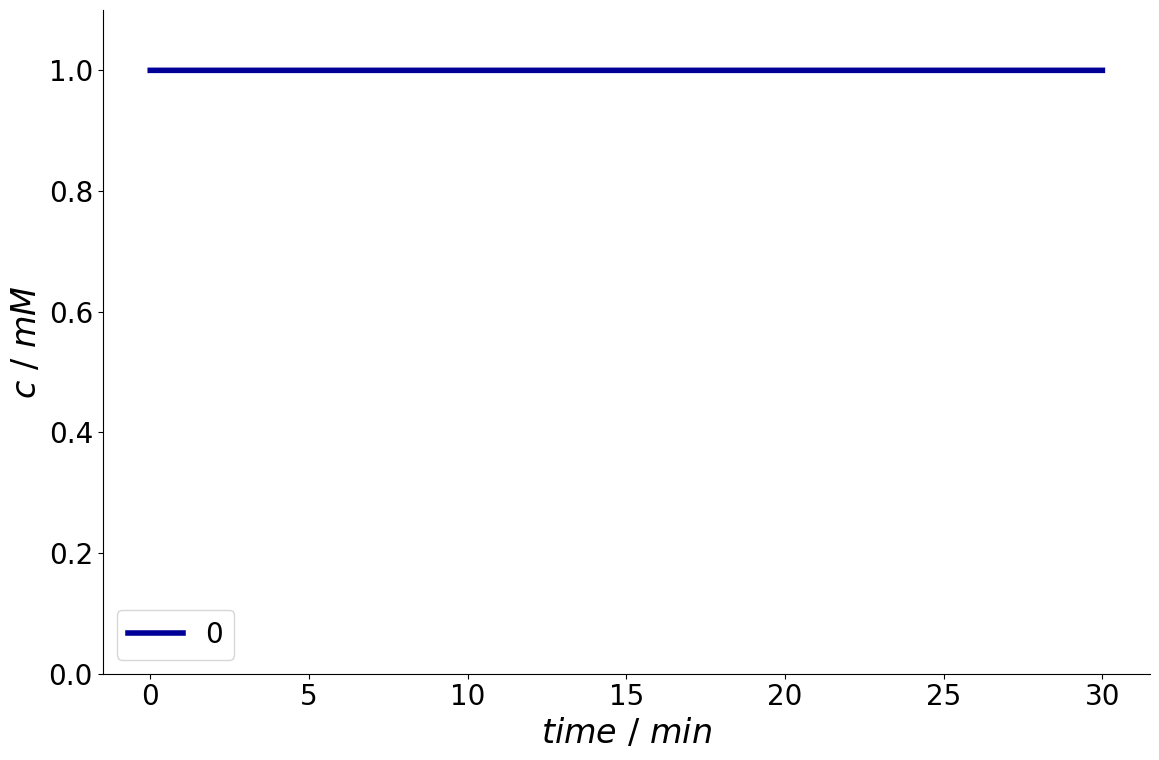

In [10]:
_ = simulation_results.solution.inlet.outlet.plot()

### Outlet Profile

Equivilantly, the outlet profile can be plot:

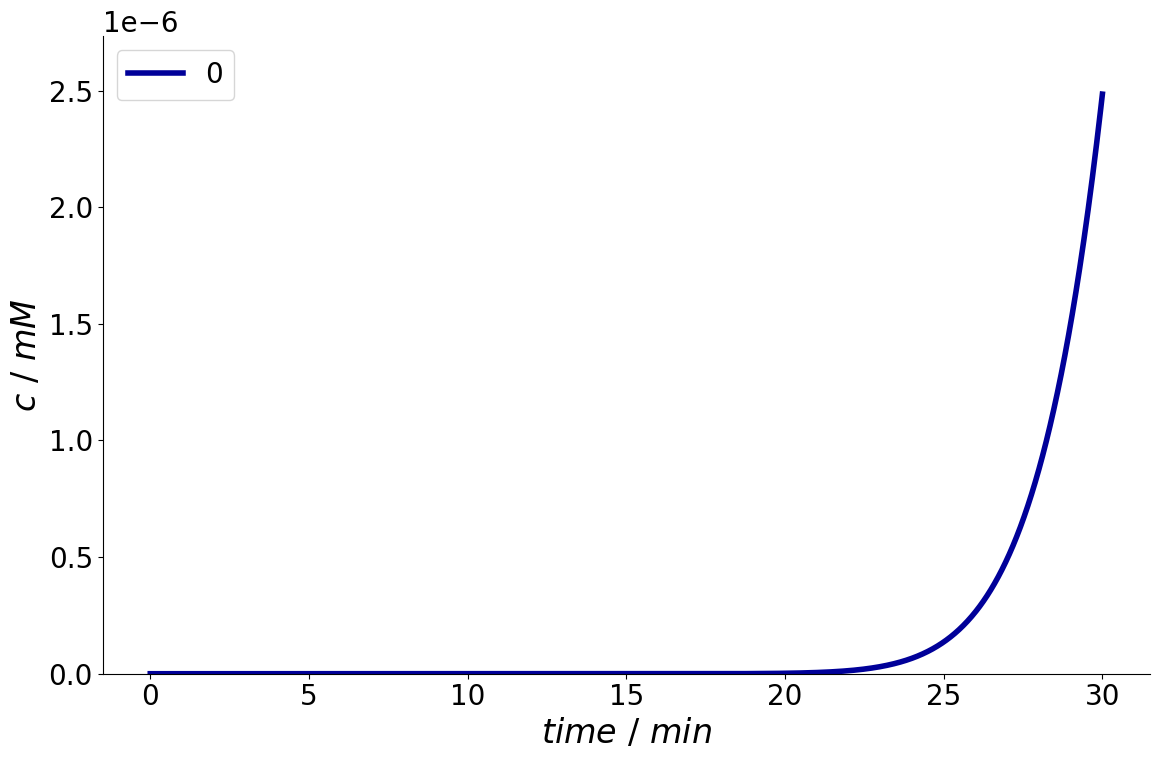

In [11]:
_ = simulation_results.solution.outlet.outlet.plot()

## Visualization

In addition to the solution at the inlet and outlet of a unit operation, we can also take a look inside the column to see the peak move.

For this purpose, set the flag in the unit's `SolutionRecorder`.
Then, the `SimulationResults` will also contain an entry for the bulk.

In [12]:
column.solution_recorder.write_solution_bulk = True

simulation_results = simulator.simulate(process)

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='$z~/~m$', ylabel='$c~/~mM$'>)

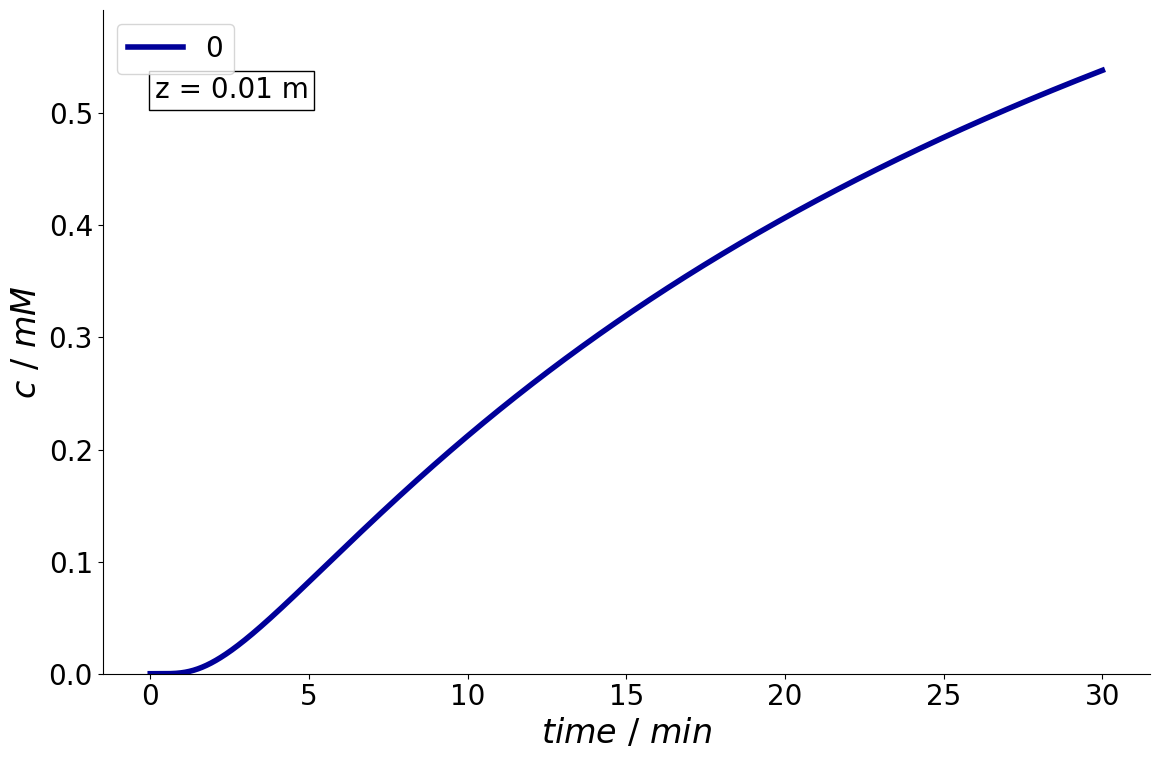

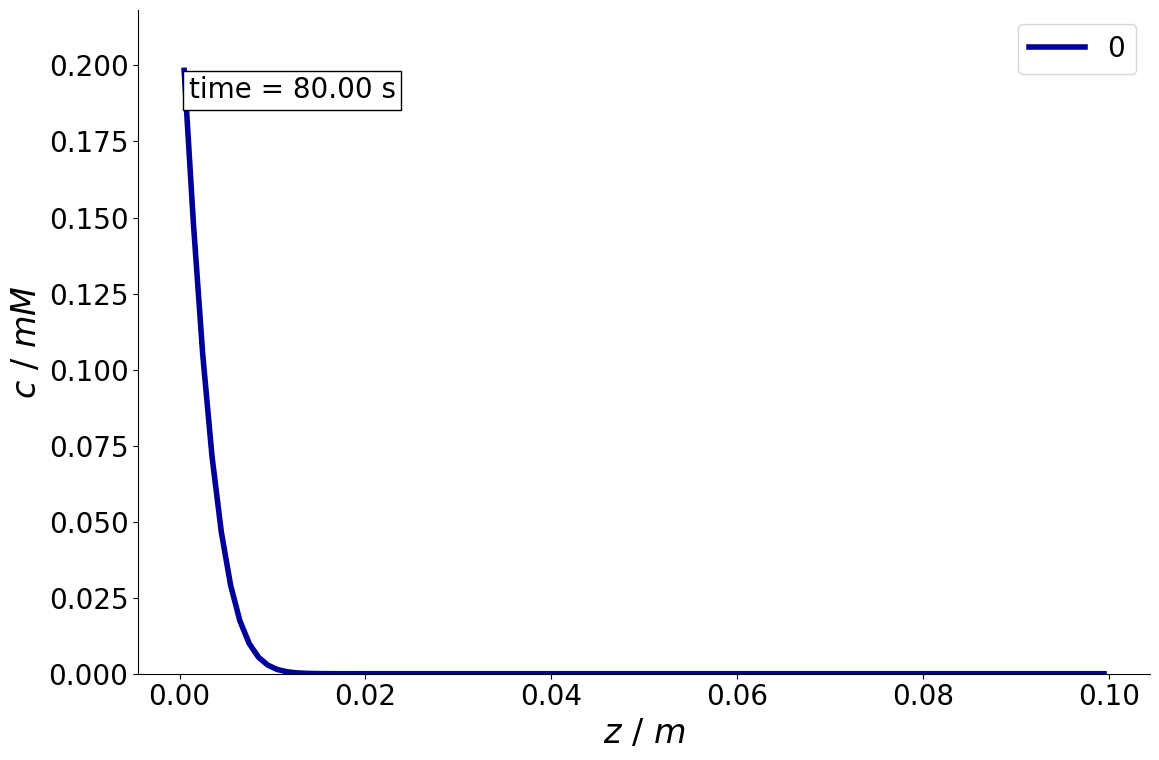

In [13]:
simulation_results.solution.column.bulk.plot_at_position(0.01)
simulation_results.solution.column.bulk.plot_at_time(80)

With ipywidgets the propagation of concentration over the whole column can be visualized for all time steps:

IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=1800, step=10, style=SliderStyle(desc…

Output()

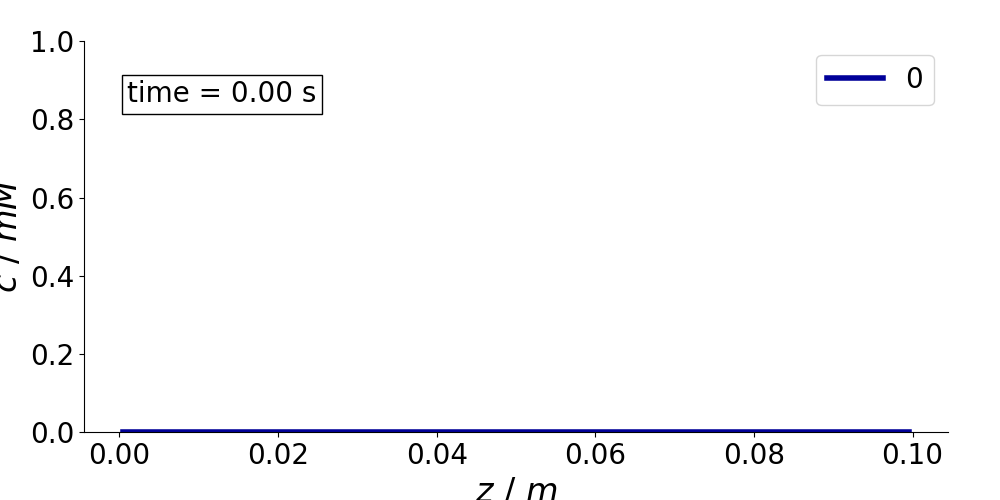

In [14]:
%matplotlib widget
from ipywidgets import IntSlider, interactive_output
import ipywidgets as widgets
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


try:
    ui.close()
except Exception:
    pass
try:
    plt.close(fig)
except Exception:
    pass

# Fresh figure
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_ylim(0, 1)
plt.tight_layout()

def draw(time=0):
    ax.cla()
    simulation_results.solution.column.bulk.plot_at_time(time, ax=ax)
    ax.set_ylim(0, 1)
    fig.canvas.draw_idle()

time_slider = IntSlider(
    min=0,
    max=int(process.cycle_time),
    step=10,
    layout={'width': '800px'},
    description='Time',
    style={'description_width': 'initial'},
)

ui = interactive_output(draw, {'time': time_slider})

display(time_slider, ui)
draw(0) 